<a href="https://colab.research.google.com/github/YineidisMarmolejo/Notebooks_Agro/blob/main/M%C3%A9todos_Num%C3%A9ricos__Trabajo_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Constantes cinéticas:
k1 = 0.0718925933630324
k2 = 0.2057662134888233
k3 = 0.04500418484395022
k4 = 0.005849122264940987

Resultados a los 50 segundos:
Concentración de Biomasa: 0.000000
Concentración de Char: 0.222810
Concentración de Tars: 0.484795
Concentración de Gas: 0.139477
Concentración de Volatiles: 0.152918


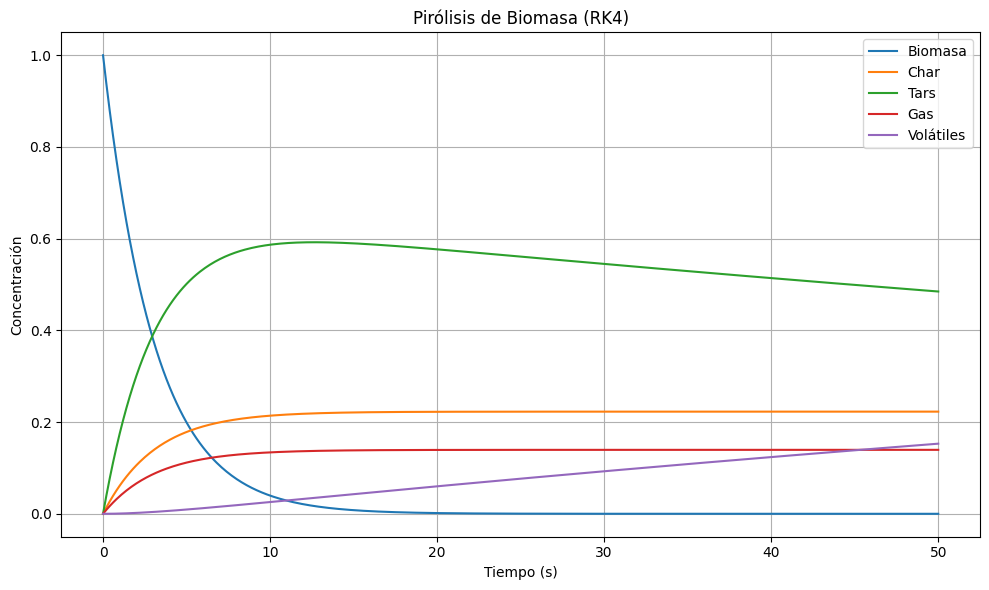

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# DATOS DE ARRHENIUS
# =====================================

R = 0.008314      # kJ/(mol*K)
T = 773           # K

## Factores preexponenciales
A1 = 1.08e7
A2 = 2.00e8
A3 = 1.30e8
A4 = 3.57e11

## Energías de activación (kJ/mol)
Ea1 = 121
Ea2 = 133
Ea3 = 140
Ea4 = 204

## Cálculo de constantes cinéticas

k1 = A1 * np.exp(-Ea1/(R*T))
k2 = A2 * np.exp(-Ea2/(R*T))
k3 = A3 * np.exp(-Ea3/(R*T))
k4 = A4 * np.exp(-Ea4/(R*T))

print("Constantes cinéticas:")
print("k1 =", k1)
print("k2 =", k2)
print("k3 =", k3)
print("k4 =", k4)

# =====================================
# CONDICIONES INICIALES
# =====================================

t0 = 0
t_final = 50
h = 0.1

# [Biomasa, Char, Tars, Gas, Volátiles]
y0 = np.array([1.0, 0.0, 0.0, 0.0, 0.0])

# =====================================
# SISTEMA DE ECUACIONES DIFERENCIALES
# =====================================

def f(t, y):

    Biomasa, Char, Tars, Gas, Volatiles = y

    dBiomasa_dt = -(k1 + k2 + k3) * Biomasa
    dChar_dt = k1 * Biomasa
    dTars_dt = k2 * Biomasa - k4 * Tars
    dGas_dt = k3 * Biomasa
    dVolatiles_dt = k4 * Tars

    return np.array([
        dBiomasa_dt,
        dChar_dt,
        dTars_dt,
        dGas_dt,
        dVolatiles_dt
    ])

# =====================================
# LISTAS PARA GUARDAR RESULTADOS
# =====================================

t_valores = [t0]
y_valores = [y0]

# =====================================
# MÉTODO RUNGE-KUTTA DE 4° ORDEN
# =====================================

t = t0
y = y0

while t < t_final:

    K1 = f(t, y)

    K2 = f(
        t + h/2,
        y + (h/2)*K1
    )

    K3 = f(
        t + h/2,
        y + (h/2)*K2
    )

    K4 = f(
        t + h,
        y + h*K3
    )

    y = y + (h/6)*(K1 + 2*K2 + 2*K3 + K4)

    t = t + h

    t_valores.append(t)
    y_valores.append(y)

# =====================================
# RESULTADOS
# =====================================

y_valores = np.array(y_valores)

especies = [
    "Biomasa",
    "Char",
    "Tars",
    "Gas",
    "Volatiles"
]

print(f"\nResultados a los {t_final} segundos:")

for i, nombre in enumerate(especies):
    print(f"Concentración de {nombre}: {y_valores[-1, i]:.6f}")

# =====================================
# GRÁFICA
# =====================================

plt.figure(figsize=(10,6))

plt.plot(t_valores, y_valores[:,0], label="Biomasa")
plt.plot(t_valores, y_valores[:,1], label="Char")
plt.plot(t_valores, y_valores[:,2], label="Tars")
plt.plot(t_valores, y_valores[:,3], label="Gas")
plt.plot(t_valores, y_valores[:,4], label="Volátiles")

plt.title("Pirólisis de Biomasa (RK4)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Concentración")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()